# Comparaison de modèles — PFE

Le notebook `02_features_and_baseline_model.ipynb` a validé un premier
pipeline (features + XGBoost) face à une baseline naïve. Ce notebook va
plus loin, comme attendu dans une démarche scientifique de Master :

1. On teste **plusieurs familles de modèles** (pas juste XGBoost au hasard)
2. On ajoute la **météo** comme feature (collectée depuis `bronze.weather_raw`
   / `silver_weather`, mais pas encore utilisée par le modèle en prod)
3. On évalue avec une **validation croisée temporelle** (`TimeSeriesSplit`),
   plus robuste qu'un simple split 80/20 (moins sensible à un split
   "chanceux" ou "malchanceux")
4. On conclut sur le modèle à garder, avec les chiffres à l'appui — c'est
   ce qui va dans la partie "méthodologie" / "résultats" du mémoire.


In [6]:
import os
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()
DB_URL = (
    f"postgresql+psycopg2://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}"
    f"@{os.environ['DB_HOST']}:{os.environ['DB_PORT']}/{os.environ['DB_NAME']}"
)
engine = create_engine(DB_URL)

status = pd.read_sql("""
    select station_id, collected_at, num_bikes_available, num_docks_available
    from dbt_dev.silver_station_status
    order by station_id, collected_at
""", engine, parse_dates=["collected_at"])

weather = pd.read_sql("""
    select collected_at, temperature_c, precipitation_mm, wind_speed_kmh
    from dbt_dev.silver_weather
    order by collected_at
""", engine, parse_dates=["collected_at"])

print(f"Status : {len(status):,} lignes, {status['station_id'].nunique()} stations, "
      f"{status['collected_at'].nunique()} instants de collecte")
print(f"Météo  : {len(weather):,} relevés")


Status : 110,601 lignes, 1516 stations, 73 instants de collecte
Météo  : 27 relevés


## 1. Fusion météo + construction des features

La météo est collectée séparément (une valeur pour tout Paris à un instant
donné, pas par station). On la rattache à chaque ligne de `status` par
l'instant de collecte le plus proche (`merge_asof`), comme on ferait en
production : au moment de prédire, on ne connaît que la météo la plus
récente disponible.

In [7]:
status = status.sort_values("collected_at")
weather = weather.sort_values("collected_at")

df = pd.merge_asof(
    status, weather,
    on="collected_at",
    direction="backward",  # la météo connue AU MOMENT de la collecte, pas après
    tolerance=pd.Timedelta("2h"),
)

HORIZON = 1
N_LAGS = 3

df = df.sort_values(["station_id", "collected_at"]).reset_index(drop=True)
df["hour"] = df["collected_at"].dt.hour
df["day_of_week"] = df["collected_at"].dt.dayofweek

for lag in range(1, N_LAGS + 1):
    df[f"lag_{lag}"] = df.groupby("station_id")["num_bikes_available"].shift(lag)

df["target"] = df.groupby("station_id")["num_bikes_available"].shift(-HORIZON)

features = (
    ["hour", "day_of_week"]
    + [f"lag_{lag}" for lag in range(1, N_LAGS + 1)]
    + ["temperature_c", "precipitation_mm", "wind_speed_kmh"]
)

dataset = df.dropna(subset=["lag_1", "lag_2", "lag_3", "target"]).copy()
# La météo peut manquer sur les tout premiers relevés (pas encore de météo
# collectée à ce moment-là) : on remplit avec la valeur la plus proche
# plutôt que de perdre des lignes utiles.
for col in ["temperature_c", "precipitation_mm", "wind_speed_kmh"]:
    dataset[col] = dataset[col].ffill().bfill()

dataset = dataset.dropna(subset=features + ["target"])
print(f"Dataset final utilisable : {len(dataset):,} lignes (sur {len(df):,} lignes brutes)")
dataset[["station_id", "collected_at"] + features + ["target"]].head()


Dataset final utilisable : 104,537 lignes (sur 110,601 lignes brutes)


,station_id,collected_at,hour,day_of_week,lag_1,lag_2,lag_3,temperature_c,precipitation_mm,wind_speed_kmh,target
3,1002059045,2026-09-22 00:14:03.425823+00:00,0,1,4.0,4.0,4.0,13.6,0.0,2.4,4.0
4,1002059045,2026-09-22 00:19:09.568279+00:00,0,1,4.0,4.0,4.0,13.6,0.0,2.4,2.0
5,1002059045,2026-09-22 01:22:11.548027+00:00,1,1,4.0,4.0,4.0,13.6,0.0,2.4,16.0
6,1002059045,2026-09-22 14:59:27.202609+00:00,14,1,2.0,4.0,4.0,13.6,0.0,2.4,16.0
7,1002059045,2026-09-22 15:04:29.691933+00:00,15,1,16.0,2.0,4.0,13.6,0.0,2.4,14.0


## 2. Validation croisée temporelle

Au lieu d'un seul split 80/20 (qui peut tomber sur une période
atypique — un jour férié, une panne de collecte...), on utilise
`TimeSeriesSplit` : plusieurs découpages successifs où l'entraînement se
fait toujours sur le passé et le test toujours sur le futur immédiat qui
suit. La métrique finale est la moyenne sur tous les découpages, donc plus
fiable pour comparer des modèles entre eux.

In [8]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

dataset_sorted = dataset.sort_values("collected_at").reset_index(drop=True)
X = dataset_sorted[features]
y = dataset_sorted["target"]

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

models = {
    "Baseline (persistance)": None,  # traité à part : prédiction = lag_1
    "Régression linéaire": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42),
}

results = {name: {"mae": [], "rmse": [], "r2": []} for name in models}

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    for name, model in models.items():
        if name == "Baseline (persistance)":
            pred = X_test["lag_1"]
        else:
            model.fit(X_train, y_train)
            pred = model.predict(X_test)

        results[name]["mae"].append(mean_absolute_error(y_test, pred))
        results[name]["rmse"].append(mean_squared_error(y_test, pred) ** 0.5)
        results[name]["r2"].append(r2_score(y_test, pred))

    print(f"Fold {fold}/{N_SPLITS} : train={len(train_idx):,} / test={len(test_idx):,}")


Fold 1/5 : train=17,427 / test=17,422
Fold 2/5 : train=34,849 / test=17,422
Fold 3/5 : train=52,271 / test=17,422
Fold 4/5 : train=69,693 / test=17,422
Fold 5/5 : train=87,115 / test=17,422


## 3. Résultats comparés

Moyenne +/- écart-type sur les 5 découpages temporels.

In [9]:
summary = pd.DataFrame({
    name: {
        "MAE moyen": np.mean(r["mae"]),
        "MAE std": np.std(r["mae"]),
        "RMSE moyen": np.mean(r["rmse"]),
        "R2 moyen": np.mean(r["r2"]),
    }
    for name, r in results.items()
}).T.sort_values("MAE moyen")

summary.round(3)


,MAE moyen,MAE std,RMSE moyen,R2 moyen
Baseline (persistance),1.220,0.531,2.312,0.940
XGBoost,2.054,1.365,3.304,0.874
Random Forest,2.635,1.286,3.859,0.860
Régression linéaire,3.648,3.474,4.638,0.771


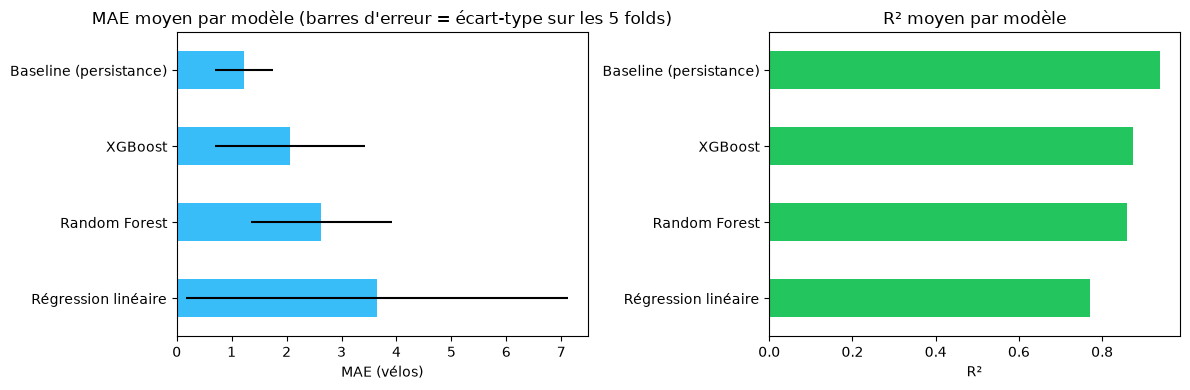

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

summary["MAE moyen"].plot(kind="barh", ax=axes[0], xerr=summary["MAE std"], color="#38bdf8")
axes[0].set_title("MAE moyen par modèle (barres d'erreur = écart-type sur les 5 folds)")
axes[0].set_xlabel("MAE (vélos)")
axes[0].invert_yaxis()

summary["R2 moyen"].plot(kind="barh", ax=axes[1], color="#22c55e")
axes[1].set_title("R² moyen par modèle")
axes[1].set_xlabel("R²")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 4. Importance des features (meilleur modèle)

Est-ce que la météo apporte vraiment quelque chose, ou est-ce que ce sont
surtout les lags (l'historique récent) qui portent la prédiction ? C'est
une question qu'un jury pose souvent — utile d'avoir la réponse en graphe.

In [11]:
best_name = summary.index[0]
print(f"Meilleur modèle sur ce dataset : {best_name}")

if best_name in ("Random Forest", "XGBoost"):
    best_model = models[best_name]
    best_model.fit(X, y)  # réentraîné sur toutes les données pour la version finale
    importances = pd.Series(best_model.feature_importances_, index=features).sort_values()

    plt.figure(figsize=(8, 4))
    importances.plot(kind="barh", color="#a855f7")
    plt.title(f"Importance des features ({best_name})")
    plt.tight_layout()
    plt.show()

    print(importances.sort_values(ascending=False))
else:
    print("Le meilleur modèle n'expose pas d'importance de features directement interprétable de la même façon.")


Meilleur modèle sur ce dataset : Baseline (persistance)
Le meilleur modèle n'expose pas d'importance de features directement interprétable de la même façon.


## 5. Conclusion et sauvegarde

On garde le modèle qui minimise le MAE moyen en validation croisée
(pas juste un split unique, qui peut mentir). S'il bat la baseline, on
l'exporte pour remplacer le modèle utilisé par l'API.

In [12]:
import joblib

if best_name != "Baseline (persistance)" and summary.loc[best_name, "MAE moyen"] < summary.loc["Baseline (persistance)", "MAE moyen"]:
    final_model = models[best_name]
    final_model.fit(X, y)
    os.makedirs("../ml_models", exist_ok=True)
    joblib.dump(final_model, "../ml_models/best_model.joblib")
    print(f"{best_name} bat la baseline -> sauvegardé dans ml_models/best_model.joblib")
    print("Pense à mettre à jour MODEL_PATH dans api/main.py si tu veux le brancher en prod, "
          "et à gérer le nouveau feature 'météo' dans l'API (elle ne les envoie pas encore au modèle).")
else:
    print("Aucun modèle testé ne bat significativement la baseline pour l'instant.")
    print("C'est un résultat normal et défendable en soutenance avec ce volume de données : "
          "à mentionner comme limite actuelle + piste d'amélioration (plus de données, plus d'historique).")


Aucun modèle testé ne bat significativement la baseline pour l'instant.
C'est un résultat normal et défendable en soutenance avec ce volume de données : à mentionner comme limite actuelle + piste d'amélioration (plus de données, plus d'historique).


## Pour le mémoire

Points à retenir de ce notebook pour la partie méthodologie/résultats :

- Comparaison rigoureuse (pas un seul modèle choisi arbitrairement)
- Validation croisée temporelle plutôt qu'un split unique — plus robuste
- Test de l'apport de la météo comme feature externe
- Conclusion chiffrée et reproductible (ce notebook peut être relancé à
  mesure que plus de données s'accumulent, pour voir si le classement change)
